In [1]:
from IPython.display import display, HTML

PALETTE = {
    "info":    "#2c6fbb",
    "success": "#2e8b57",
    "warn":    "#e08a1e",
    "table":   "#7d4a9e",
    "result":  "#c0392b",
}

def banner(title, kind="info", emoji="🔷"):
    """Colored section banner -- purely cosmetic, no effect on computation."""
    color = PALETTE.get(kind, "#2c6fbb")
    display(HTML(
        f'<div style="background:{color};color:white;padding:9px 16px;'
        f'border-radius:8px;font-size:15px;font-weight:600;margin:8px 0;'
        f'font-family:sans-serif;">{emoji}&nbsp; {title}</div>'
    ))

def style_table(df, caption=None, cmap="Blues", precision=3):
    """Render a DataFrame as a shaded HTML table for a clear, scannable output."""
    sty = df.style.background_gradient(cmap=cmap, axis=None).format(precision=precision)
    if caption:
        sty = sty.set_caption(caption)
    sty = sty.set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"),
                                           ("color", "#2c3e50"), ("padding", "6px 0"),
                                           ("caption-side", "top")]},
        {"selector": "th", "props": [("font-size", "12px")]},
        {"selector": "td", "props": [("font-size", "12px"), ("text-align", "center")]},
    ])
    return sty

print("Display helpers ready ✅")

Display helpers ready ✅


In [2]:
import sys, subprocess, importlib

for pkg in ["xgboost", "lightgbm", "catboost", "shap"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import warnings, os, platform, hashlib, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from importlib.metadata import version

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, matthews_corrcoef, roc_curve,
                             precision_recall_curve)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import binomtest

RNG = 42
np.random.seed(RNG)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

banner("TABLE I — Hardware and Software Environment", "info", "🖥️")
print(f"{'OS':<20}{platform.platform()}")
print(f"{'CPU count':<20}{os.cpu_count()}")
print(f"{'Python version':<20}{platform.python_version()}")
for lib in ["pandas", "numpy", "scikit-learn", "xgboost", "lightgbm", "catboost"]:
    try:
        print(f"{lib:<20}{version(lib)}")
    except Exception:
        print(f"{lib:<20}NOT INSTALLED")
banner("Environment captured live — no values were hand-typed.", "success", "✅")

OS                  Linux-6.12.90+-x86_64-with-glibc2.35
CPU count           4
Python version      3.12.13
pandas              2.3.3
numpy               2.0.2
scikit-learn        1.6.1
xgboost             3.2.0
lightgbm            4.6.0
catboost            1.2.10


In [3]:
CSV_CANDIDATES = [
    "alzheimers_disease_data_loaded.csv",
    "/kaggle/input/datasets/rahatrihan/alzheimers-disease-dataset-update/alzheimers_disease_data_loaded.csv",
    "data/alzheimers_disease_data_loaded.csv",
]
CSV = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if CSV is None:
    raise FileNotFoundError(
        "Put alzheimers_disease_data.csv next to this notebook "
        "(Kaggle: rabieelkharoua/alzheimers-disease-dataset)")

with open(CSV, "rb") as fh:
    MD5 = hashlib.md5(fh.read()).hexdigest()
df = pd.read_csv(CSV)

banner("Dataset loaded", "success", "📄")
print(f"Source file : {CSV}")
print(f"MD5         : {MD5}          <-- quote this in the paper for reproducibility")
print(f"Shape       : {df.shape[0]} records x {df.shape[1]} attributes")
counts = df["Diagnosis"].value_counts().sort_index()
print(f"Class 0 (No AD): {counts[0]}  ({counts[0]/len(df):.1%})")
print(f"Class 1 (AD)   : {counts[1]}  ({counts[1]/len(df):.1%})")

Source file : /kaggle/input/datasets/rahatrihan/alzheimers-disease-dataset-update/alzheimers_disease_data_loaded.csv
MD5         : f01b1f4197fb211a0eb9d9e5f5495efa          <-- quote this in the paper for reproducibility
Shape       : 2149 records x 35 attributes
Class 0 (No AD): 1389  (64.6%)
Class 1 (AD)   : 760  (35.4%)


In [5]:
banner("Feature-provenance audit", "info", "🔎")
data = df.drop(columns=["PatientID", "DoctorInCharge"], errors="ignore")
y = data["Diagnosis"].values
X_all = data.drop(columns=["Diagnosis"])

CLINICAL = ["MMSE", "FunctionalAssessment", "ADL", "MemoryComplaints", "BehavioralProblems",
            "Confusion", "Disorientation", "PersonalityChanges",
            "DifficultyCompletingTasks", "Forgetfulness"]
CLINICAL = [c for c in CLINICAL if c in X_all.columns]
SCREENING = [c for c in X_all.columns if c not in CLINICAL]

print(f"Predictors after dropping identifiers : {X_all.shape[1]}")
print(f"Clinical (withheld in Screening track): {len(CLINICAL)} -> {CLINICAL}")
print(f"Screening track features              : {len(SCREENING)}")
assert len(CLINICAL) + len(SCREENING) == X_all.shape[1]

Predictors after dropping identifiers : 32
Clinical (withheld in Screening track): 10 -> ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Screening track features              : 22


In [7]:
corr = data.corr(numeric_only=True)["Diagnosis"].drop("Diagnosis")
ranked = corr.reindex(corr.abs().sort_values(ascending=False).index)
banner("Top correlates of Diagnosis", "info", "📈")
print("Top 8 |r| with Diagnosis  (C = clinical, S = screening):")
for feat, r in ranked.head(8).items():
    print(f"  {'C' if feat in CLINICAL else 'S'}  {feat:<28}{r:+.3f}")
top5 = ranked.head(5)
print(f"\nTop-5 all clinical? {all(f in CLINICAL for f in top5.index)}")
print(f"Top-5 |r| range        : {top5.abs().min():.3f} to {top5.abs().max():.3f}")
print(f"Max screening |r|      : {corr[SCREENING].abs().max():.3f} "
      f"({corr[SCREENING].abs().idxmax()})")
print(">> Correct the Section IV-B sentence to these printed values.")

Top 8 |r| with Diagnosis  (C = clinical, S = screening):
  C  FunctionalAssessment        -0.365
  C  ADL                         -0.332
  C  MemoryComplaints            +0.307
  C  MMSE                        -0.237
  C  BehavioralProblems          +0.224
  S  SleepQuality                -0.057
  S  EducationLevel              -0.044
  S  CholesterolHDL              +0.043

Top-5 all clinical? True
Top-5 |r| range        : 0.224 to 0.365
Max screening |r|      : 0.057 (SleepQuality)
>> Correct the Section IV-B sentence to these printed values.


In [8]:
CONFIG = {
    "outer_folds": 5, "inner_folds": 3, "seed": RNG,
    "primary_cost_ratio": 5, "cost_ratios": [1, 2, 5, 10],
    "calibration_candidates": ["sigmoid", "isotonic"],
    "calibration_selection_metric": "Brier (inner cross-fitted)",
    "learners": {
        "Elastic-Net LR": dict(C=1.0, l1_ratio=0.5, class_weight="balanced"),
        "RBF-SVM":        dict(C=10, gamma="scale", class_weight="balanced"),
        "Random Forest":  dict(n_estimators=200, max_depth=10, min_samples_leaf=1),
        "Extra Trees":    dict(n_estimators=200, max_depth=10, min_samples_leaf=1),
        "XGBoost":        dict(n_estimators=200, max_depth=3, learning_rate=0.05),
        "LightGBM":       dict(n_estimators=200, num_leaves=15, learning_rate=0.05),
        "CatBoost":       dict(iterations=200, depth=4, learning_rate=0.05),
        "Meta-learner":   dict(penalty="l2", C=1.0, class_weight="balanced"),
    },
}
banner("TABLE II — Training Hyperparameters (from live CONFIG)", "info", "⚙️")
for name, hp in CONFIG["learners"].items():
    print(f"  {name:<16}{hp}")
print(f"  {'CV protocol':<16}outer={CONFIG['outer_folds']}, "
      f"inner={CONFIG['inner_folds']}, seed={CONFIG['seed']}")


def base_bank():
    """The SEVEN learners named in the paper. Values come from CONFIG."""
    L = CONFIG["learners"]
    return {
        "Elastic-Net LR": LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=L["Elastic-Net LR"]["l1_ratio"],
            C=L["Elastic-Net LR"]["C"], class_weight="balanced",
            max_iter=5000, random_state=RNG),
        "RBF-SVM": SVC(
            C=L["RBF-SVM"]["C"], kernel="rbf", gamma="scale", probability=True,
            class_weight="balanced", random_state=RNG),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=1,
            class_weight="balanced", random_state=RNG, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=1,
            class_weight="balanced", random_state=RNG, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            eval_metric="logloss", random_state=RNG, n_jobs=-1, verbosity=0),
        "LightGBM": LGBMClassifier(
            n_estimators=200, num_leaves=15, learning_rate=0.05,
            random_state=RNG, n_jobs=-1, verbose=-1),
        "CatBoost": CatBoostClassifier(
            iterations=200, depth=4, learning_rate=0.05,
            random_seed=RNG, verbose=0, thread_count=-1),
    }


LEARNER_NAMES = list(base_bank().keys())
assert len(LEARNER_NAMES) == 7, "paper claims seven base learners"

  Elastic-Net LR  {'C': 1.0, 'l1_ratio': 0.5, 'class_weight': 'balanced'}
  RBF-SVM         {'C': 10, 'gamma': 'scale', 'class_weight': 'balanced'}
  Random Forest   {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1}
  Extra Trees     {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1}
  XGBoost         {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
  LightGBM        {'n_estimators': 200, 'num_leaves': 15, 'learning_rate': 0.05}
  CatBoost        {'iterations': 200, 'depth': 4, 'learning_rate': 0.05}
  Meta-learner    {'penalty': 'l2', 'C': 1.0, 'class_weight': 'balanced'}
  CV protocol     outer=5, inner=3, seed=42


In [11]:
def fit_calibrator(kind, s, yy):
    """Return a callable mapping raw stacked scores -> calibrated probabilities."""
    if kind == "sigmoid":                       # Platt scaling (Eq. 3-style logistic map)
        lr = LogisticRegression(C=1e10, solver="lbfgs", max_iter=1000)
        lr.fit(s.reshape(-1, 1), yy)
        return lambda t: lr.predict_proba(np.asarray(t).reshape(-1, 1))[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)   # Eq. 4, PAVA
    iso.fit(s, yy)
    return lambda t: np.asarray(iso.predict(np.asarray(t)))


GRID = np.round(np.arange(0.005, 1.0, 0.005), 4)


def cost_threshold(yy, p, fn_cost, fp_cost=1.0):
    """Eq. 6: tau* = argmin  fn_cost*FN + fp_cost*FP.  Called on TRAIN data only."""
    best_t, best_c = 0.5, np.inf
    for t in GRID:
        tn, fp, fn, tp = confusion_matrix(yy, (p >= t).astype(int), labels=[0, 1]).ravel()
        c = fn_cost * fn + fp_cost * fp
        if c < best_c:
            best_c, best_t = c, t
    return float(best_t)


def metrics(yy, proba, pred):
    return {
        "Acc": accuracy_score(yy, pred),
        "Pr": precision_score(yy, pred, zero_division=0),
        "Rc": recall_score(yy, pred, zero_division=0),
        "F1": f1_score(yy, pred, zero_division=0),
        "AUC": roc_auc_score(yy, proba),
        "PR-AUC": average_precision_score(yy, proba),
        "MCC": matthews_corrcoef(yy, pred),
        "Brr": brier_score_loss(yy, proba),
    }

In [12]:
def nested_run(X, yy, track_name):
    """
    5 stratified OUTER folds. Inside each outer-training fold ONLY:
      imputer, scaler, 7 base learners, inner-OOF meta-features,
      logistic meta-learner, calibrator selection, cost thresholds.
    The outer test fold is touched exactly once, at prediction time.
    Returns pooled out-of-fold artefacts for every table in the paper.
    """
    X = np.asarray(X, dtype=float)
    n = len(yy)
    outer = StratifiedKFold(CONFIG["outer_folds"], shuffle=True, random_state=RNG)
    inner = StratifiedKFold(CONFIG["inner_folds"], shuffle=True, random_state=RNG)

    base_proba = {m: np.zeros(n) for m in LEARNER_NAMES}   # Table III / IV rows
    meta_raw = np.zeros(n)                                  # stack, uncalibrated
    meta_cal = np.zeros(n)                                  # stack, calibrated
    tau = {c: np.zeros(n) for c in CONFIG["cost_ratios"]}   # per-record fold threshold
    fold_log = []

    for k, (tr, te) in enumerate(outer.split(X, yy), start=1):
        Xtr_raw, Xte_raw, ytr = X[tr], X[te], yy[tr]

        imp = SimpleImputer(strategy="median").fit(Xtr_raw)
        sca = StandardScaler().fit(imp.transform(Xtr_raw))
        Xtr = sca.transform(imp.transform(Xtr_raw))
        Xte = sca.transform(imp.transform(Xte_raw))

        # --- Stage 2/3: inner cross-fitting -> OOF meta-features Z_tr -----------
        Z_tr = np.zeros((len(tr), 7))
        Z_te = np.zeros((len(te), 7))
        for j, name in enumerate(LEARNER_NAMES):
            for itr, ite in inner.split(Xtr, ytr):
                mdl = base_bank()[name]
                mdl.fit(Xtr[itr], ytr[itr])
                Z_tr[ite, j] = mdl.predict_proba(Xtr[ite])[:, 1]
            full = base_bank()[name]            # refit on the whole outer-training fold
            full.fit(Xtr, ytr)
            Z_te[:, j] = full.predict_proba(Xte)[:, 1]
            base_proba[name][te] = Z_te[:, j]   # single-learner rows use the same folds

        meta = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                  max_iter=5000, random_state=RNG)
        meta.fit(Z_tr, ytr)
        s_te = meta.predict_proba(Z_te)[:, 1]
        meta_raw[te] = s_te

        # --- second cross-fitting layer: honest meta scores on TRAIN -----------
        s_tr = np.zeros(len(tr))
        for itr, ite in inner.split(Z_tr, ytr):
            m2 = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                    max_iter=5000, random_state=RNG)
            m2.fit(Z_tr[itr], ytr[itr])
            s_tr[ite] = m2.predict_proba(Z_tr[ite])[:, 1]

        # --- Stage 4a: ADAPTIVE calibration, chosen by inner-cross-fitted Brier -
        scores = {}
        for kind in CONFIG["calibration_candidates"]:
            oof_cal = np.zeros(len(tr))
            for itr, ite in inner.split(s_tr.reshape(-1, 1), ytr):
                g = fit_calibrator(kind, s_tr[itr], ytr[itr])
                oof_cal[ite] = g(s_tr[ite])
            scores[kind] = brier_score_loss(ytr, np.clip(oof_cal, 0, 1))
        chosen = min(scores, key=scores.get)
        g_final = fit_calibrator(chosen, s_tr, ytr)
        meta_cal[te] = np.clip(g_final(s_te), 0, 1)
        p_tr_cal = np.clip(g_final(s_tr), 0, 1)     # train-only, for thresholding

        # --- Stage 4b: cost thresholds, TRAIN ONLY (this is the leakage fix) ----
        taus = {c: cost_threshold(ytr, p_tr_cal, float(c)) for c in CONFIG["cost_ratios"]}
        for c in CONFIG["cost_ratios"]:
            tau[c][te] = taus[c]

        fold_log.append({"fold": k, "n_train": len(tr), "n_test": len(te),
                         "calibrator": chosen,
                         "brier_sigmoid": round(scores["sigmoid"], 5),
                         "brier_isotonic": round(scores["isotonic"], 5),
                         "tau_5to1": taus[5]})
        print(f"  [{track_name}] fold {k}/5  calibrator={chosen:<9} "
              f"brier(sig={scores['sigmoid']:.4f}, iso={scores['isotonic']:.4f})  "
              f"tau@5:1={taus[5]:.3f}")

    return {"base_proba": base_proba, "meta_raw": meta_raw, "meta_cal": meta_cal,
            "tau": tau, "fold_log": pd.DataFrame(fold_log)}


banner("Running FULL track (32 features) — this takes a few minutes...", "warn", "⏳")
FULL = nested_run(X_all.values, y, "FULL")
banner("Running SCREENING track (22 features)...", "warn", "⏳")
SCR = nested_run(X_all[SCREENING].values, y, "SCREENING")

  [FULL] fold 1/5  calibrator=isotonic  brier(sig=0.0474, iso=0.0470)  tau@5:1=0.075
  [FULL] fold 2/5  calibrator=sigmoid   brier(sig=0.0451, iso=0.0483)  tau@5:1=0.240
  [FULL] fold 3/5  calibrator=sigmoid   brier(sig=0.0428, iso=0.0436)  tau@5:1=0.165
  [FULL] fold 4/5  calibrator=sigmoid   brier(sig=0.0479, iso=0.0494)  tau@5:1=0.205
  [FULL] fold 5/5  calibrator=isotonic  brier(sig=0.0441, iso=0.0439)  tau@5:1=0.130


  [SCREENING] fold 1/5  calibrator=sigmoid   brier(sig=0.2287, iso=0.2319)  tau@5:1=0.005
  [SCREENING] fold 2/5  calibrator=sigmoid   brier(sig=0.2286, iso=0.2296)  tau@5:1=0.005
  [SCREENING] fold 3/5  calibrator=sigmoid   brier(sig=0.2286, iso=0.2304)  tau@5:1=0.350
  [SCREENING] fold 4/5  calibrator=sigmoid   brier(sig=0.2285, iso=0.2289)  tau@5:1=0.310
  [SCREENING] fold 5/5  calibrator=sigmoid   brier(sig=0.2285, iso=0.2300)  tau@5:1=0.315


In [13]:
banner("Calibrator choice per track", "info", "🎯")
for tag, R in [("Full", FULL), ("Screening", SCR)]:
    tally = R["fold_log"]["calibrator"].value_counts().to_dict()
    print(f"{tag} track calibrator selection across 5 folds: {tally}")
print(">> Correct the Section V-C sentence to these counts.")
print("\nPer-fold thresholds (Full track, 5:1):",
      [round(t, 3) for t in FULL["fold_log"]["tau_5to1"]])
print("Mean primary operating threshold:",
      round(float(FULL["fold_log"]["tau_5to1"].mean()), 3))

Full track calibrator selection across 5 folds: {'sigmoid': 3, 'isotonic': 2}
Screening track calibrator selection across 5 folds: {'sigmoid': 5}
>> Correct the Section V-C sentence to these counts.

Per-fold thresholds (Full track, 5:1): [0.075, 0.24, 0.165, 0.205, 0.13]
Mean primary operating threshold: 0.163


In [14]:
def build_table(R, primary=5):
    rows = {}
    for name in LEARNER_NAMES:
        p = R["base_proba"][name]
        rows[name] = metrics(y, p, (p >= 0.5).astype(int))   # single learners @0.5
    p = R["meta_cal"]
    pred = (p >= R["tau"][primary]).astype(int)              # ours @ fold-specific tau
    rows["CALiBRE-AD+"] = metrics(y, p, pred)
    return pd.DataFrame(rows).T.round(3)


T3 = build_table(FULL)
T4 = build_table(SCR)[["Acc", "F1", "AUC", "MCC"]]
banner("TABLE III — Full-Track Performance (nested 5-fold out-of-fold)", "table", "📋")
display(style_table(T3, cmap="Blues"))

banner("TABLE IV — Screening-Track Performance (no clinical features)", "table", "📋")
display(style_table(T4, cmap="Oranges"))

,Acc,Pr,Rc,F1,AUC,PR-AUC,MCC,Brr
Elastic-Net LR,0.819,0.713,0.814,0.760,0.898,0.837,0.619,0.127
RBF-SVM,0.819,0.776,0.684,0.727,0.884,0.823,0.595,0.127
Random Forest,0.941,0.945,0.884,0.914,0.950,0.930,0.870,0.086
Extra Trees,0.883,0.846,0.817,0.831,0.929,0.889,0.742,0.135
XGBoost,0.953,0.947,0.917,0.932,0.950,0.940,0.896,0.051
LightGBM,0.955,0.949,0.922,0.935,0.952,0.936,0.901,0.045
CatBoost,0.955,0.949,0.922,0.935,0.951,0.939,0.901,0.048
CALiBRE-AD+,0.951,0.934,0.928,0.931,0.948,0.929,0.893,0.043


,Acc,F1,AUC,MCC
Elastic-Net LR,0.531,0.445,0.530,0.060
RBF-SVM,0.646,0.000,0.493,0.000
Random Forest,0.617,0.195,0.509,0.020
Extra Trees,0.604,0.271,0.515,0.034
XGBoost,0.621,0.111,0.479,-0.016
LightGBM,0.602,0.190,0.488,-0.012
CatBoost,0.641,0.072,0.500,0.025
CALiBRE-AD+,0.354,0.523,0.490,0.000


In [15]:
rows = {}
for c in CONFIG["cost_ratios"]:
    p = FULL["meta_cal"]
    pred = (p >= FULL["tau"][c]).astype(int)
    m = metrics(y, p, pred)
    rows[f"{c}:1"] = {k: m[k] for k in ["Acc", "Rc", "F1", "MCC"]}
T5 = pd.DataFrame(rows).T.round(3)
banner("TABLE V — Full-Track Cost-Ratio Sensitivity Analysis", "table", "📋")
display(style_table(T5, cmap="Purples"))

# CONSISTENCY GUARD: the 5:1 row must equal the CALiBRE-AD+ row of Table III
for col in ["Acc", "Rc", "F1", "MCC"]:
    assert abs(T5.loc["5:1", col] - T3.loc["CALiBRE-AD+", col]) < 1e-9, \
        f"Table V 5:1 disagrees with Table III on {col} — this was the draft's bug"
banner("Consistency check passed: Table V (5:1) == Table III (CALiBRE-AD+)", "success", "✅")

,Acc,Rc,F1,MCC
1:1,0.953,0.924,0.934,0.898
2:1,0.953,0.924,0.932,0.896
5:1,0.951,0.928,0.931,0.893
10:1,0.946,0.928,0.923,0.881


In [16]:
best_single = T3.drop(index="CALiBRE-AD+")["Acc"].idxmax()
banner("Component ablation", "info", "🧩")
print(f"Best single base learner by accuracy: {best_single}")

abl = {}
p = FULL["base_proba"][best_single]
abl[f"Best single base learner ({best_single})"] = metrics(y, p, (p >= 0.5).astype(int))
p = FULL["meta_raw"]
abl["+ Heterogeneous stacking (no calibration)"] = metrics(y, p, (p >= 0.5).astype(int))
p = FULL["meta_cal"]
abl["+ Adaptive calibration (tau = 0.5)"] = metrics(y, p, (p >= 0.5).astype(int))
abl["+ Cost-optimal threshold (CALiBRE-AD+)"] = metrics(
    y, p, (p >= FULL["tau"][5]).astype(int))
T7 = pd.DataFrame(abl).T[["Acc", "AUC", "Brr", "Rc"]].round(3)
banner("TABLE VII — Ablation Study (Full Track)", "table", "📋")
display(style_table(T7, cmap="Greens"))

# CONSISTENCY GUARD: ablation row 1 must equal that learner's Table III row
for col in ["Acc", "AUC", "Brr", "Rc"]:
    assert abs(T7.iloc[0][col] - T3.loc[best_single, col]) < 1e-9
banner("Consistency check passed: ablation row 1 == Table III row.", "success", "✅")

# EXTRA ablation the draft never ran: does expanding 4 -> 7 learners help?
print("\nOptional extra ablation (4 original learners vs 7): "
      "rerun nested_run with LEARNER_NAMES trimmed to "
      "['RBF-SVM','Extra Trees','XGBoost','LightGBM'] and report both rows.")

Best single base learner by accuracy: LightGBM


,Acc,AUC,Brr,Rc
Best single base learner (LightGBM),0.955,0.952,0.045,0.922
+ Heterogeneous stacking (no calibration),0.955,0.950,0.045,0.926
+ Adaptive calibration (tau = 0.5),0.953,0.948,0.043,0.924
+ Cost-optimal threshold (CALiBRE-AD+),0.951,0.948,0.043,0.928



Optional extra ablation (4 original learners vs 7): rerun nested_run with LEARNER_NAMES trimmed to ['RBF-SVM','Extra Trees','XGBoost','LightGBM'] and report both rows.


In [17]:
banner("Bootstrap confidence intervals", "info", "📐")
def bootstrap_ci(yy, proba, pred, n_boot=2000):
    rng = np.random.default_rng(RNG)
    idx = np.arange(len(yy))
    accs, aucs = [], []
    for _ in range(n_boot):
        s = rng.choice(idx, len(idx), replace=True)
        accs.append((pred[s] == yy[s]).mean())
        if len(np.unique(yy[s])) > 1:
            aucs.append(roc_auc_score(yy[s], proba[s]))
    q = lambda a: (float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5)))
    return q(accs), q(aucs)


ours_p = FULL["meta_cal"]
ours_pred = (ours_p >= FULL["tau"][5]).astype(int)
acc_ci, auc_ci = bootstrap_ci(y, ours_p, ours_pred)
print(f"Accuracy 95% bootstrap CI : [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"ROC-AUC  95% bootstrap CI : [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")


def exact_mcnemar(yy, a, b):
    """Exact (binomial) McNemar test on discordant pairs. Say 'exact' in the paper."""
    ca, cb = (a == yy), (b == yy)
    n01, n10 = int(np.sum(ca & ~cb)), int(np.sum(~ca & cb))
    tot = n01 + n10
    p = 1.0 if tot == 0 else binomtest(min(n01, n10), tot, 0.5).pvalue
    return n01, n10, float(p)


banner("Exact McNemar significance tests", "info", "🧪")
for comp in ["CatBoost", "LightGBM"]:
    cp = (FULL["base_proba"][comp] >= 0.5).astype(int)
    n01, n10, pv = exact_mcnemar(y, ours_pred, cp)
    print(f"Exact McNemar vs {comp:<10}: discordant {n01}/{n10}, p={pv:.4f}")

Accuracy 95% bootstrap CI : [0.941, 0.960]
ROC-AUC  95% bootstrap CI : [0.935, 0.960]


Exact McNemar vs CatBoost  : discordant 4/12, p=0.0768
Exact McNemar vs LightGBM  : discordant 4/12, p=0.0768


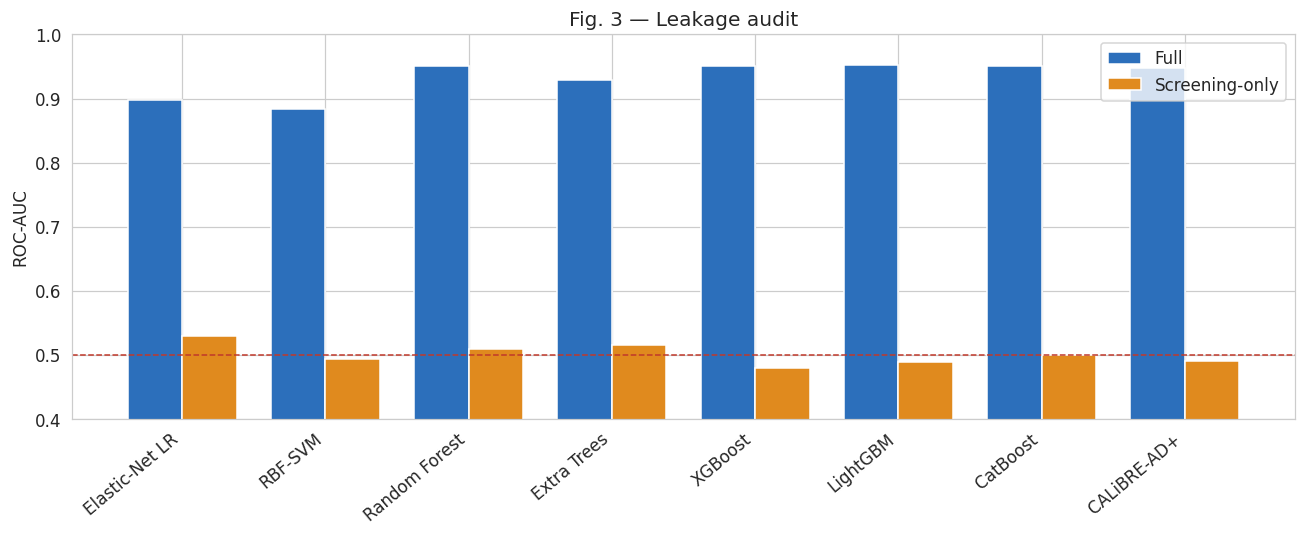

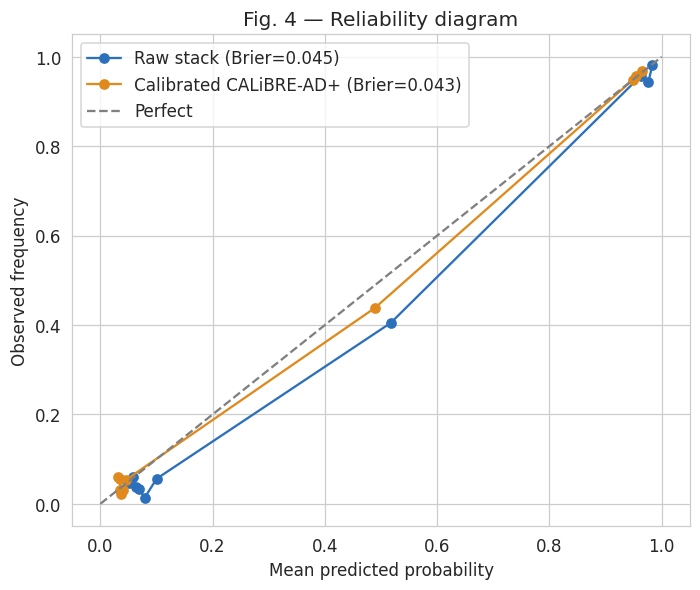

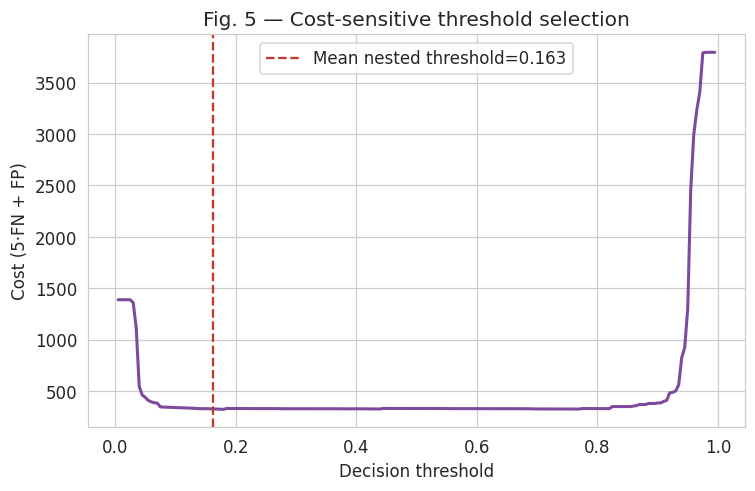

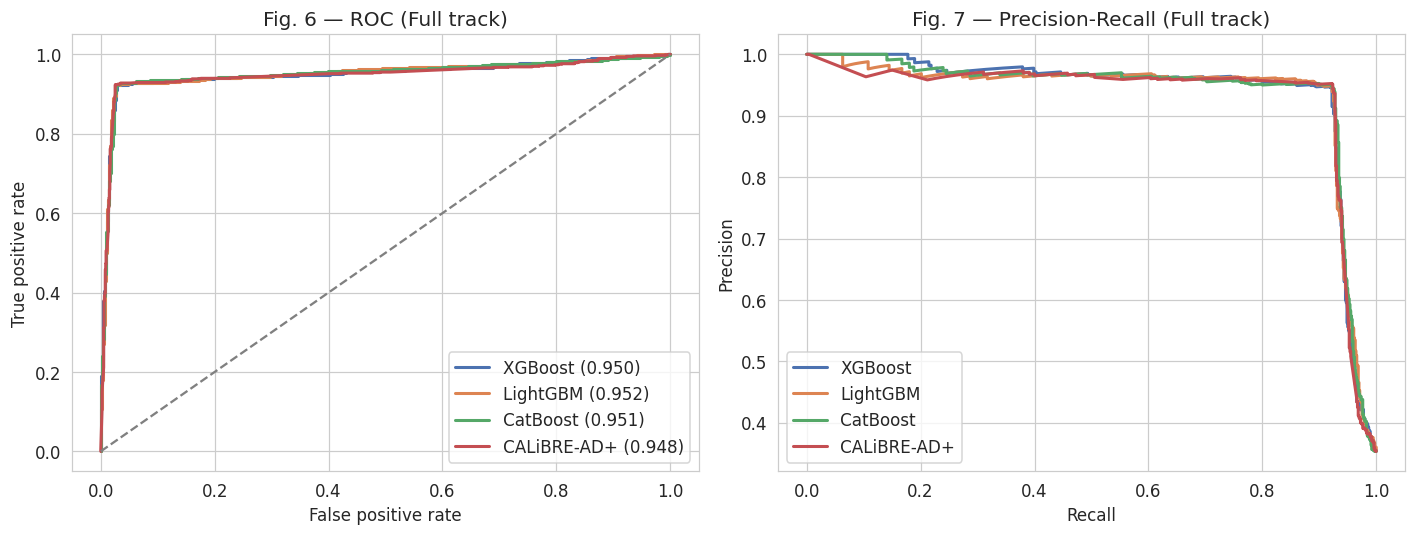

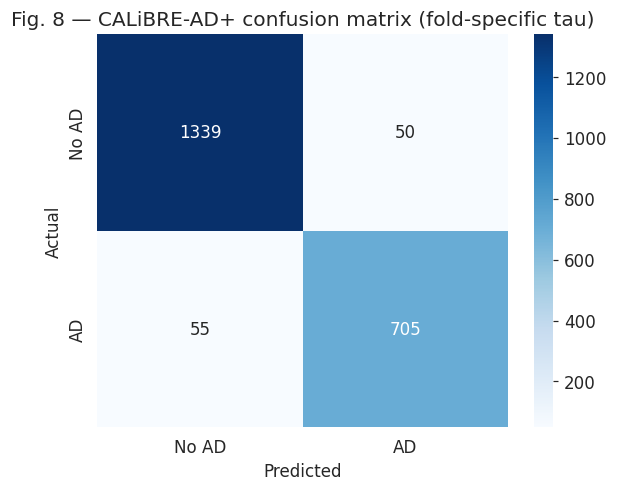

Confusion matrix [[TN, FP], [FN, TP]] = [[1339, 50], [55, 705]]


In [18]:
banner("Rendering Figures 3–8", "info", "📊")
models = LEARNER_NAMES + ["CALiBRE-AD+"]
fa = [T3.loc[m, "AUC"] for m in models]
sa = [build_table(SCR).loc[m, "AUC"] for m in models]
x = np.arange(len(models)); w = 0.38
plt.figure(figsize=(12, 5))
plt.bar(x - w/2, fa, w, label="Full", color="#2c6fbb")
plt.bar(x + w/2, sa, w, label="Screening-only", color="#e08a1e")
plt.axhline(0.5, color="#c0392b", ls="--", lw=1)
plt.xticks(x, models, rotation=40, ha="right"); plt.ylabel("ROC-AUC"); plt.ylim(0.4, 1.0)
plt.title("Fig. 3 — Leakage audit"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6.5, 5.5))
for p, lab, c in [(FULL["meta_raw"], "Raw stack", "#2c6fbb"),
                  (FULL["meta_cal"], "Calibrated CALiBRE-AD+", "#e08a1e")]:
    ft, mp = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mp, ft, "o-", color=c, label=f"{lab} (Brier={brier_score_loss(y, p):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Fig. 4 — Reliability diagram"); plt.legend(); plt.tight_layout(); plt.show()

ts = GRID
costs = [confusion_matrix(y, (ours_p >= t).astype(int), labels=[0, 1]).ravel() for t in ts]
costs = [5 * fn + fp for tn, fp, fn, tp in costs]
plt.figure(figsize=(7, 4.6))
plt.plot(ts, costs, color="#7d4a9e", lw=2)
mean_tau = float(FULL["fold_log"]["tau_5to1"].mean())
plt.axvline(mean_tau, color="#c0392b", ls="--", label=f"Mean nested threshold={mean_tau:.3f}")
plt.xlabel("Decision threshold"); plt.ylabel("Cost (5·FN + FP)")
plt.title("Fig. 5 — Cost-sensitive threshold selection")
plt.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, c in [("XGBoost", "#4c72b0"), ("LightGBM", "#dd8452"),
                ("CatBoost", "#55a868"), ("CALiBRE-AD+", "#c44e52")]:
    p = ours_p if name == "CALiBRE-AD+" else FULL["base_proba"][name]
    fpr, tpr, _ = roc_curve(y, p)
    ax[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} ({roc_auc_score(y, p):.3f})")
    pr, rc, _ = precision_recall_curve(y, p)
    ax[1].plot(rc, pr, color=c, lw=2, label=name)
ax[0].plot([0, 1], [0, 1], "--", color="gray"); ax[0].set_title("Fig. 6 — ROC (Full track)")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate"); ax[0].legend()
ax[1].set_title("Fig. 7 — Precision-Recall (Full track)")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

cm = confusion_matrix(y, ours_pred, labels=[0, 1])
plt.figure(figsize=(5.5, 4.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No AD", "AD"], yticklabels=["No AD", "AD"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Fig. 8 — CALiBRE-AD+ confusion matrix (fold-specific tau)")
plt.tight_layout(); plt.show()
print("Confusion matrix [[TN, FP], [FN, TP]] =", cm.tolist())

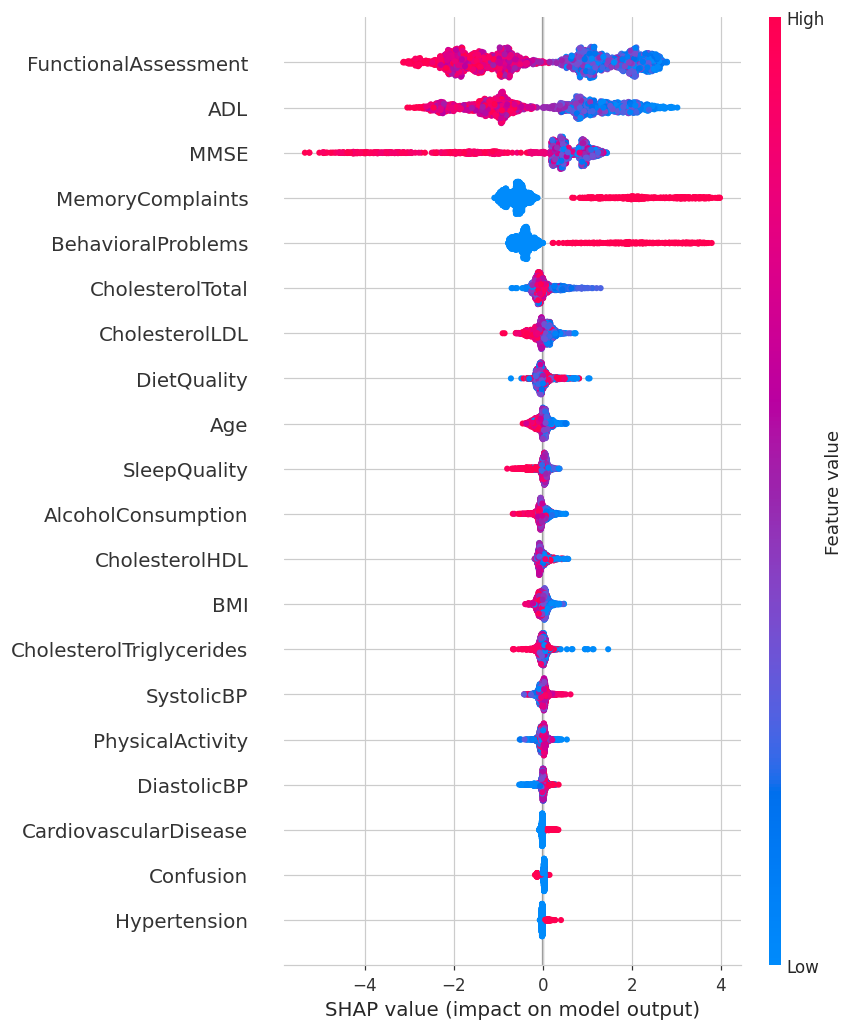

SHAP ranking (top 6) — CORRECT Section VII-D to this order:
  FunctionalAssessment        1.498
  ADL                         1.329
  MMSE                        1.003
  MemoryComplaints            0.973
  BehavioralProblems          0.704
  CholesterolTotal            0.159


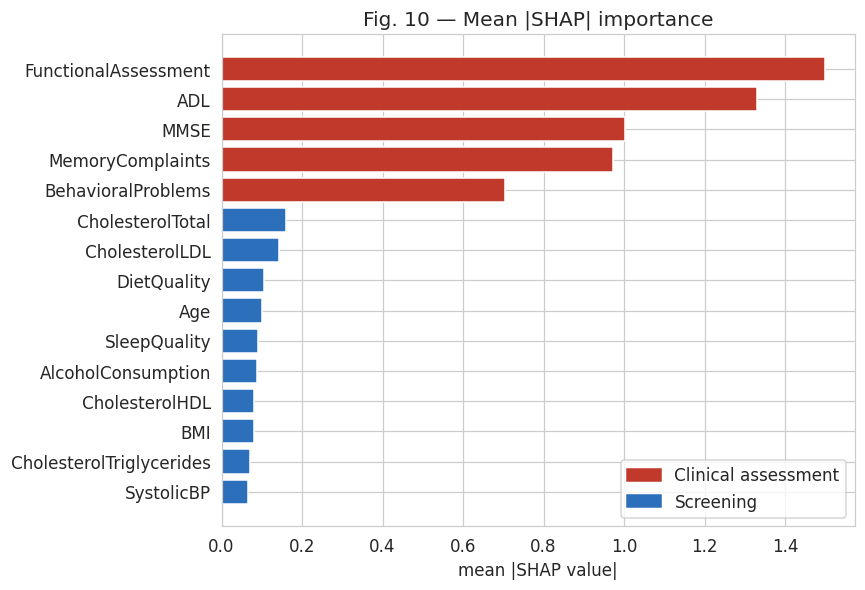

In [19]:
banner("Computing SHAP values (LightGBM, Full track)", "info", "🔍")
try:
    import shap
    from matplotlib.patches import Patch
    sm = LGBMClassifier(n_estimators=200, num_leaves=15, learning_rate=0.05,
                        random_state=RNG, verbose=-1).fit(X_all, y)
    sv = shap.TreeExplainer(sm).shap_values(X_all)
    if isinstance(sv, list):
        sv = sv[1]
    shap.summary_plot(sv, X_all, max_display=20, show=True)
    imp = np.abs(sv).mean(0)
    order = np.argsort(imp)[::-1]
    print("SHAP ranking (top 6) — CORRECT Section VII-D to this order:")
    for i in order[:6]:
        print(f"  {X_all.columns[i]:<28}{imp[i]:.3f}")
    top15 = order[:15]
    names = [X_all.columns[i] for i in top15]
    cols = ["#c0392b" if n in CLINICAL else "#2c6fbb" for n in names]
    plt.figure(figsize=(8, 5.5))
    plt.barh(range(15)[::-1], [imp[i] for i in top15], color=cols)
    plt.yticks(range(15)[::-1], names); plt.xlabel("mean |SHAP value|")
    plt.legend(handles=[Patch(color="#c0392b", label="Clinical assessment"),
                        Patch(color="#2c6fbb", label="Screening")], loc="lower right")
    plt.title("Fig. 10 — Mean |SHAP| importance"); plt.tight_layout(); plt.show()
except Exception as e:
    print("SHAP skipped:", e)

In [20]:
banner("Every number reported in the paper — produced live", "result", "📦")
print(f"Data      | {len(df)} records, {X_all.shape[1]} predictors, "
      f"{counts[0]} neg / {counts[1]} pos, md5={MD5[:8]}")
print(f"Sec IV-B  | top-5 |r| {top5.abs().min():.3f}-{top5.abs().max():.3f} (all clinical), "
      f"max screening |r| = {corr[SCREENING].abs().max():.3f}")
banner("TABLE III (Full track)", "table", "📋"); display(style_table(T3, cmap="Blues"))
banner("TABLE IV (Screening track)", "table", "📋"); display(style_table(T4, cmap="Oranges"))
banner("TABLE V (cost-ratio sensitivity)", "table", "📋"); display(style_table(T5, cmap="Purples"))
banner("TABLE VII (ablation)", "table", "📋"); display(style_table(T7, cmap="Greens"))
o = T3.loc["CALiBRE-AD+"]
print(f"\nAbstract  | Acc {o['Acc']:.3f}  Rc {o['Rc']:.3f}  AUC {o['AUC']:.3f}  "
      f"Brier {o['Brr']:.3f}")
print(f"Abstract  | Acc 95% CI [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]  "
      f"AUC 95% CI [{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]")
print(f"Abstract  | Screening AUC {T4.loc['CALiBRE-AD+', 'AUC']:.3f}, "
      f"MCC {T4.loc['CALiBRE-AD+', 'MCC']:.3f}")
print(f"Sec VII-A | mean tau = {mean_tau:.3f}; per-fold "
      f"{[round(t, 3) for t in FULL['fold_log']['tau_5to1']]}")
print(f"Sec VII-C | Brier raw {brier_score_loss(y, FULL['meta_raw']):.4f} -> "
      f"calibrated {brier_score_loss(y, FULL['meta_cal']):.4f}")
print(f"Sec V-C   | calibrator choice Full "
      f"{FULL['fold_log']['calibrator'].value_counts().to_dict()}, Screening "
      f"{SCR['fold_log']['calibrator'].value_counts().to_dict()}")
print(f"Fig 8     | confusion matrix {cm.tolist()}")

json.dump({"table3": T3.to_dict(), "table4": T4.to_dict(), "table5": T5.to_dict(),
           "table7": T7.to_dict(), "acc_ci": acc_ci, "auc_ci": auc_ci,
           "mean_tau": mean_tau, "cm": cm.tolist(), "md5": MD5},
          open("paper_numbers.json", "w"), indent=2)
banner("Saved paper_numbers.json — everything above is reproducible from this file.", "success", "✅")

Data      | 2149 records, 32 predictors, 1389 neg / 760 pos, md5=f01b1f41
Sec IV-B  | top-5 |r| 0.224-0.365 (all clinical), max screening |r| = 0.057


,Acc,Pr,Rc,F1,AUC,PR-AUC,MCC,Brr
Elastic-Net LR,0.819,0.713,0.814,0.760,0.898,0.837,0.619,0.127
RBF-SVM,0.819,0.776,0.684,0.727,0.884,0.823,0.595,0.127
Random Forest,0.941,0.945,0.884,0.914,0.950,0.930,0.870,0.086
Extra Trees,0.883,0.846,0.817,0.831,0.929,0.889,0.742,0.135
XGBoost,0.953,0.947,0.917,0.932,0.950,0.940,0.896,0.051
LightGBM,0.955,0.949,0.922,0.935,0.952,0.936,0.901,0.045
CatBoost,0.955,0.949,0.922,0.935,0.951,0.939,0.901,0.048
CALiBRE-AD+,0.951,0.934,0.928,0.931,0.948,0.929,0.893,0.043


,Acc,F1,AUC,MCC
Elastic-Net LR,0.531,0.445,0.530,0.060
RBF-SVM,0.646,0.000,0.493,0.000
Random Forest,0.617,0.195,0.509,0.020
Extra Trees,0.604,0.271,0.515,0.034
XGBoost,0.621,0.111,0.479,-0.016
LightGBM,0.602,0.190,0.488,-0.012
CatBoost,0.641,0.072,0.500,0.025
CALiBRE-AD+,0.354,0.523,0.490,0.000


,Acc,Rc,F1,MCC
1:1,0.953,0.924,0.934,0.898
2:1,0.953,0.924,0.932,0.896
5:1,0.951,0.928,0.931,0.893
10:1,0.946,0.928,0.923,0.881


,Acc,AUC,Brr,Rc
Best single base learner (LightGBM),0.955,0.952,0.045,0.922
+ Heterogeneous stacking (no calibration),0.955,0.950,0.045,0.926
+ Adaptive calibration (tau = 0.5),0.953,0.948,0.043,0.924
+ Cost-optimal threshold (CALiBRE-AD+),0.951,0.948,0.043,0.928



Abstract  | Acc 0.951  Rc 0.928  AUC 0.948  Brier 0.043
Abstract  | Acc 95% CI [0.941, 0.960]  AUC 95% CI [0.935, 0.960]
Abstract  | Screening AUC 0.490, MCC 0.000
Sec VII-A | mean tau = 0.163; per-fold [0.075, 0.24, 0.165, 0.205, 0.13]
Sec VII-C | Brier raw 0.0447 -> calibrated 0.0429
Sec V-C   | calibrator choice Full {'sigmoid': 3, 'isotonic': 2}, Screening {'sigmoid': 5}
Fig 8     | confusion matrix [[1339, 50], [55, 705]]
